# Fraud Detection - PaySim Dataset
## Objective
Detect fraudulent transactions in a highly imbalanced financial dataset 
using XGBoost with SHAP explainability.

## Dataset
- 6.3 million transactions
- Only 0.13% fraud cases — extreme class imbalance

In [62]:
import pandas as pd
import numpy as np 
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

In [63]:
# Load PaySim dataset - 6.3M synthetic financial transactions
df = pd.read_csv('raw.csv')  

## Data Exploration

In [64]:
df.head()

,step,type,amount,nameOrig,oldbalanceOrg,newbalanceOrig,nameDest,oldbalanceDest,newbalanceDest,isFraud,isFlaggedFraud
0,1,PAYMENT,9839.64,C1231006815,170136.0,160296.36,M1979787155,0.0,0.0,0,0
1,1,PAYMENT,1864.28,C1666544295,21249.0,19384.72,M2044282225,0.0,0.0,0,0
2,1,TRANSFER,181.00,C1305486145,181.0,0.00,C553264065,0.0,0.0,1,0
3,1,CASH_OUT,181.00,C840083671,181.0,0.00,C38997010,21182.0,0.0,1,0
4,1,PAYMENT,11668.14,C2048537720,41554.0,29885.86,M1230701703,0.0,0.0,0,0


In [65]:
df.columns

Index(['step', 'type', 'amount', 'nameOrig', 'oldbalanceOrg', 'newbalanceOrig',
       'nameDest', 'oldbalanceDest', 'newbalanceDest', 'isFraud',
       'isFlaggedFraud'],
      dtype='object')

In [66]:
df.describe()

,step,amount,oldbalanceOrg,newbalanceOrig,oldbalanceDest,newbalanceDest,isFraud,isFlaggedFraud
count,6.362620e+06,6.362620e+06,6.362620e+06,6.362620e+06,6.362620e+06,6.362620e+06,6.362620e+06,6.362620e+06
mean,2.433972e+02,1.798619e+05,8.338831e+05,8.551137e+05,1.100702e+06,1.224996e+06,1.290820e-03,2.514687e-06
std,1.423320e+02,6.038582e+05,2.888243e+06,2.924049e+06,3.399180e+06,3.674129e+06,3.590480e-02,1.585775e-03
min,1.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00
25%,1.560000e+02,1.338957e+04,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00
50%,2.390000e+02,7.487194e+04,1.420800e+04,0.000000e+00,1.327057e+05,2.146614e+05,0.000000e+00,0.000000e+00
75%,3.350000e+02,2.087215e+05,1.073152e+05,1.442584e+05,9.430367e+05,1.111909e+06,0.000000e+00,0.000000e+00
max,7.430000e+02,9.244552e+07,5.958504e+07,4.958504e+07,3.560159e+08,3.561793e+08,1.000000e+00,1.000000e+00


In [67]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6362620 entries, 0 to 6362619
Data columns (total 11 columns):
 #   Column          Dtype  
---  ------          -----  
 0   step            int64  
 1   type            object 
 2   amount          float64
 3   nameOrig        object 
 4   oldbalanceOrg   float64
 5   newbalanceOrig  float64
 6   nameDest        object 
 7   oldbalanceDest  float64
 8   newbalanceDest  float64
 9   isFraud         int64  
 10  isFlaggedFraud  int64  
dtypes: float64(5), int64(3), object(3)
memory usage: 534.0+ MB


In [68]:
df['isFraud'].value_counts()

isFraud
0    6354407
1       8213
Name: count, dtype: int64

In [69]:
# Drop target, redundant fraud label, and account IDs (unique per row - no signal)
X = df.drop(['isFraud','isFlaggedFraud','nameOrig', 'nameDest'], axis=1)
y= df['isFraud']

## Class Imbalance Analysis
Only 8,213 fraud cases out of 6.3M transactions (0.13%)
A naive model predicting all non-fraud would still show 99.8% accuracy 
but catch zero fraud cases.

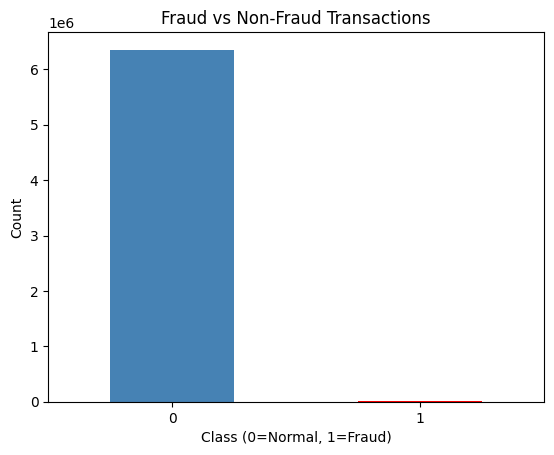

In [70]:
## Class Distribution
y.value_counts().plot(kind='bar', color=['steelblue', 'red'])
plt.title('Fraud vs Non-Fraud Transactions')
plt.xlabel('Class (0=Normal, 1=Fraud)')
plt.ylabel('Count')
plt.xticks(rotation=0)
plt.show()

In [71]:
# One-hot encode transaction type — ML models need numbers, not text
# drop_first=True removes redundant column (n-1 columns enough for n categories)
X = pd.get_dummies(X,columns=['type'], drop_first=True)

In [72]:
X.head()

,step,amount,oldbalanceOrg,newbalanceOrig,oldbalanceDest,newbalanceDest,type_CASH_OUT,type_DEBIT,type_PAYMENT,type_TRANSFER
0,1,9839.64,170136.0,160296.36,0.0,0.0,False,False,True,False
1,1,1864.28,21249.0,19384.72,0.0,0.0,False,False,True,False
2,1,181.00,181.0,0.00,0.0,0.0,False,False,False,True
3,1,181.00,181.0,0.00,21182.0,0.0,True,False,False,False
4,1,11668.14,41554.0,29885.86,0.0,0.0,False,False,True,False


## Train-Test Split

In [73]:
from sklearn.model_selection import train_test_split

In [74]:
# stratify=y ensures same fraud ratio (0.13%) in both train and test sets
# Critical for imbalanced datasets — without this, fraud cases may be unevenly distributed
X_train, X_test, y_train, y_test = train_test_split(
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.20, random_state=42, stratify=y) 

SyntaxError: incomplete input (766668399.py, line 4)

## Handling Class Imbalance — scale_pos_weight

In [ ]:
fraud_count = y_train.sum()
non_fraud_count = len(y_train) - fraud_count
scale = non_fraud_count/fraud_count

print(f"Fraud cases: {fraud_count}")
print(f"Non fraud cases: {non_fraud_count}")
print(f"Scale pos weight: {scale:.2f}")

In [ ]:
# scale_pos_weight = non_fraud/fraud = 773
# Model receives 773x more penalty for missing a fraud case
# This forces the model to take minority class seriously

## Model Training — XGBoost

In [ ]:
from xgboost import XGBClassifier
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score

In [ ]:
xgb_model = XGBClassifier( n_estimator = 100, learning_rate = 0.1, max_depth = 3, scale_pos_weight = scale, random_state = 42, eval_metric = 'logloss')

In [ ]:
xgb_model.fit(X_train, y_train)

In [ ]:
y_pred= xgb_model.predict(X_test)
y_pred_proba = xgb_model.predict_proba(X_test)[:,1]

In [ ]:
# y_pred — binary 0/1 using default 0.5 threshold
# y_pred_proba — raw probabilities, allows custom threshold tuning
# In fraud detection, banks often lower threshold to 0.2-0.3 to catch more fraud

## Model Evaluation

In [ ]:
print(classification_report(y_test,y_pred))
print("ROC_AUC Score :", roc_auc_score(y_test, y_pred_proba))

In [ ]:
# Recall = 1.00 — every fraud transaction detected 
# Precision = 0.06 — acceptable tradeoff in fraud detection
# Missing fraud >> False alarm in terms of business cost
# ROC-AUC = 0.999 — model perfectly distinguishes fraud from non-fraud

## Model Explainability — SHAP Analysis

In [ ]:
import shap

explainer = shap.TreeExplainer(xgb_model)
shap_values = explainer.shap_values(X_test[:1000])

shap.summary_plot(shap_values, X_test[:1000])

In [ ]:
# SHAP explains WHY the model made each prediction
# Key insight: newbalanceOrig is strongest fraud signal
# When sender's balance gets wiped to zero, highest fraud probability